🍋 데이터 소스: 마이홈포털_공공주택 단지정보 (활용신청 필요)

brtcCode: 11로 하면 데이터를 가져오면 "서울에서 임대주택이 가장 많은 자치구 Top 10

API에서 데이터를 처음 가져오면, 파이썬은 이 데이터가 숫자인지 문자인지 잘 모름. 보통 '문자열(String)' 상태로 가져오는 경우가 많습니다.

문자열 상태 ("100"): "100" + "200"을 하면 수학적인 합계 300이 아니라, 글자가 붙어버린 "100200"이 됩니다. (계산 불가)

숫자 상태 (100): 100 + 200 = 300으로 정상적인 통계 계산이 가능해집니다.

즉, 합계(sum), 평균(mean), 최댓값(max) 같은 분석을 하려면 반드시 이 과정을 거쳐야 합니다.

2. pd.to_numeric(..., errors='coerce')의 역할
이 코드는 일종의 **'안전한 숫자 변환기'**입니다.

변환 작업: df['hshldCo'] 열에 있는 값들을 하나씩 꺼내서 숫자로 바꿉니다.

errors='coerce'의 의미: 만약 데이터 중에 "정보없음"이나 "-" 같은 글자가 섞여 있어서 숫자로 바꿀 수 없을 때, 에러를 내며 멈추는 대신 **NaN(Not a Number, 결측치)**으로 표시하고 일단 넘어가라는 뜻입니다. (매우 유용한 옵션입니다!)

c:\Users\miran\AppData\Local\Programs\Python\Python311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data.myhome.go.kr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


총 374건의 데이터를 수집했습니다.
signguNm
종로구    374
Name: count, dtype: int64


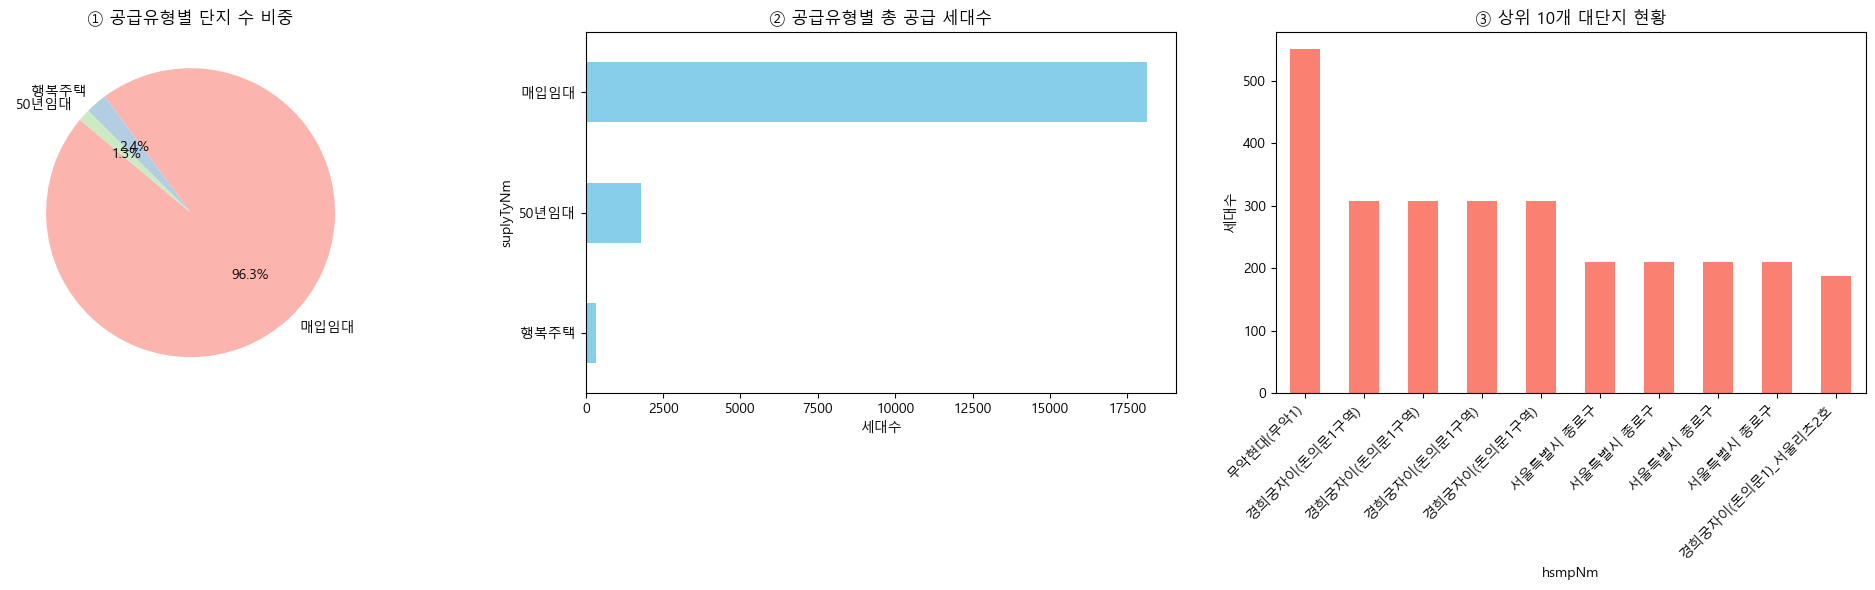

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt  # pyplot으로 수정

base_url = "https://data.myhome.go.kr:443/rentalHouseList" 
service_key = "6114f483bd6368bb21a7995881e36487d6baeae732d0dcdd3c719842dd0d35ed"

params = {
    'ServiceKey': service_key,
    'brtcCode': '11', # 광역시도: 서울특별시 (11)
    'signguCode': '110', # 시군구: 종로구 (110)
    'numOfRows': '1000', #2️⃣1000건으로
    'pageNo': '1',    
}

# 2️⃣데이터 호출
response = requests.get(base_url, params=params, verify=False)
data = response.json() #🍋
df = pd.DataFrame(data['hsmpList']) #🟠hsmpList만 추출(단지목록)
print(f"총 {len(df)}건의 데이터를 수집했습니다.")

# 엑셀 저장 (확인 후 닫기 - 열어보고 있으면 오류🍋)
# df.to_excel('LH_save.xlsx', index=False)
# print("--- LH_save.xlsx 파일 저장 완료! ---") #\n줄바꿈

# 3️⃣시군구별(signguNm)='I' 단지 수 집계
region_counts = df['signguNm'].value_counts()
print(region_counts)

#시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#🟠 데이터 전처리 (hsmpList 데이터 타입을 🍋숫자로 바꿈) 세대수
df['hshldCo'] = pd.to_numeric(df['hshldCo'], errors='coerce')

# 도표를 그리기 위한 Figure 생성 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# [도표 1] 공급유형별 단지 수 비중
supply_counts = df['suplyTyNm'].value_counts()
axes[0].pie(supply_counts, labels=supply_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
axes[0].set_title('① 공급유형별 단지 수 비중')

# [도표 2] 공급유형별 총 세대수 합계
supply_hshld_sum = df.groupby('suplyTyNm')['hshldCo'].sum().sort_values(ascending=True)
supply_hshld_sum.plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('② 공급유형별 총 공급 세대수')
axes[1].set_xlabel('세대수')

# [도표 3] 세대수 상위 10개 단지 현황
top10_hsmp = df.nlargest(10, 'hshldCo')[['hsmpNm', 'hshldCo']].set_index('hsmpNm')
top10_hsmp['hshldCo'].plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('③ 상위 10개 대단지 현황')
axes[2].set_ylabel('세대수')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

🍋CCTV 데이터 소스:
 전국무인교통단속카메라표준데이터(활용신청 필요) 안됨🧧